In [1]:
import os
import sys
import argparse

import pandas as pd
import seaborn as sns
import scikit_posthocs as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
from matplotlib.legend_handler import HandlerBase

from data import *
from utils import *
from scipy import stats
from datetime import datetime
from scipy.stats import kruskal

sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Disentanglement'))
sys.path.append(os.path.join(os.getcwd(), '..', '..', 'Accuracy'))

from DCI import compute_dci, report_dci
from IRS import compute_irs_from_multihot_labels, compute_irs
from MIG import compute_mig

from BA import oh_binary_accuracy

In [2]:
df = pd.read_csv('./data/Attack-A-Results.csv')

In [3]:
df.head()

,model,image_attack,sketch_attack,Clean_IM_Loss,FGSM_IM_Loss,BIM_IM_Loss,Clean_SK_Loss,FGSM_SK_Loss,BIM_SK_Loss,Clean_LA_Loss,FGSM_LA_Loss,BIM_LA_Loss
0,3V,True,True,0.014524,0.239832,0.181438,0.059129,0.074593,0.066791,0.001540,0.038809,0.010188
1,3V,True,True,0.015393,0.220886,0.165209,0.059679,0.074099,0.066236,0.000997,0.015301,0.006461
2,3V,True,True,0.014677,0.224152,0.166810,0.056570,0.071467,0.063751,0.001310,0.043505,0.008856
3,3V,True,True,0.015958,0.242522,0.182911,0.057411,0.072124,0.064613,0.001788,0.037404,0.008774
4,3V,True,True,0.015271,0.240027,0.181095,0.058963,0.074115,0.066429,0.001093,0.029024,0.008979


In [4]:
mean_clean_loss = (
    df[
        (df['image_attack'] == True) &
        (df['sketch_attack'] == False)
    ]
    .groupby(['model', 'image_attack', 'sketch_attack'])[
        ['Clean_IM_Loss', 'FGSM_IM_Loss', 'BIM_IM_Loss']
    ]
    .mean()
    .reset_index()
)

In [5]:
mean_clean_loss

,model,image_attack,sketch_attack,Clean_IM_Loss,FGSM_IM_Loss,BIM_IM_Loss
0,1V,True,False,0.011886,0.126960,0.073916
1,2V-IL,True,False,0.014399,0.158764,0.099357
2,2V-IS,True,False,0.015343,0.177584,0.116842
3,3V,True,False,0.015168,0.237791,0.179206


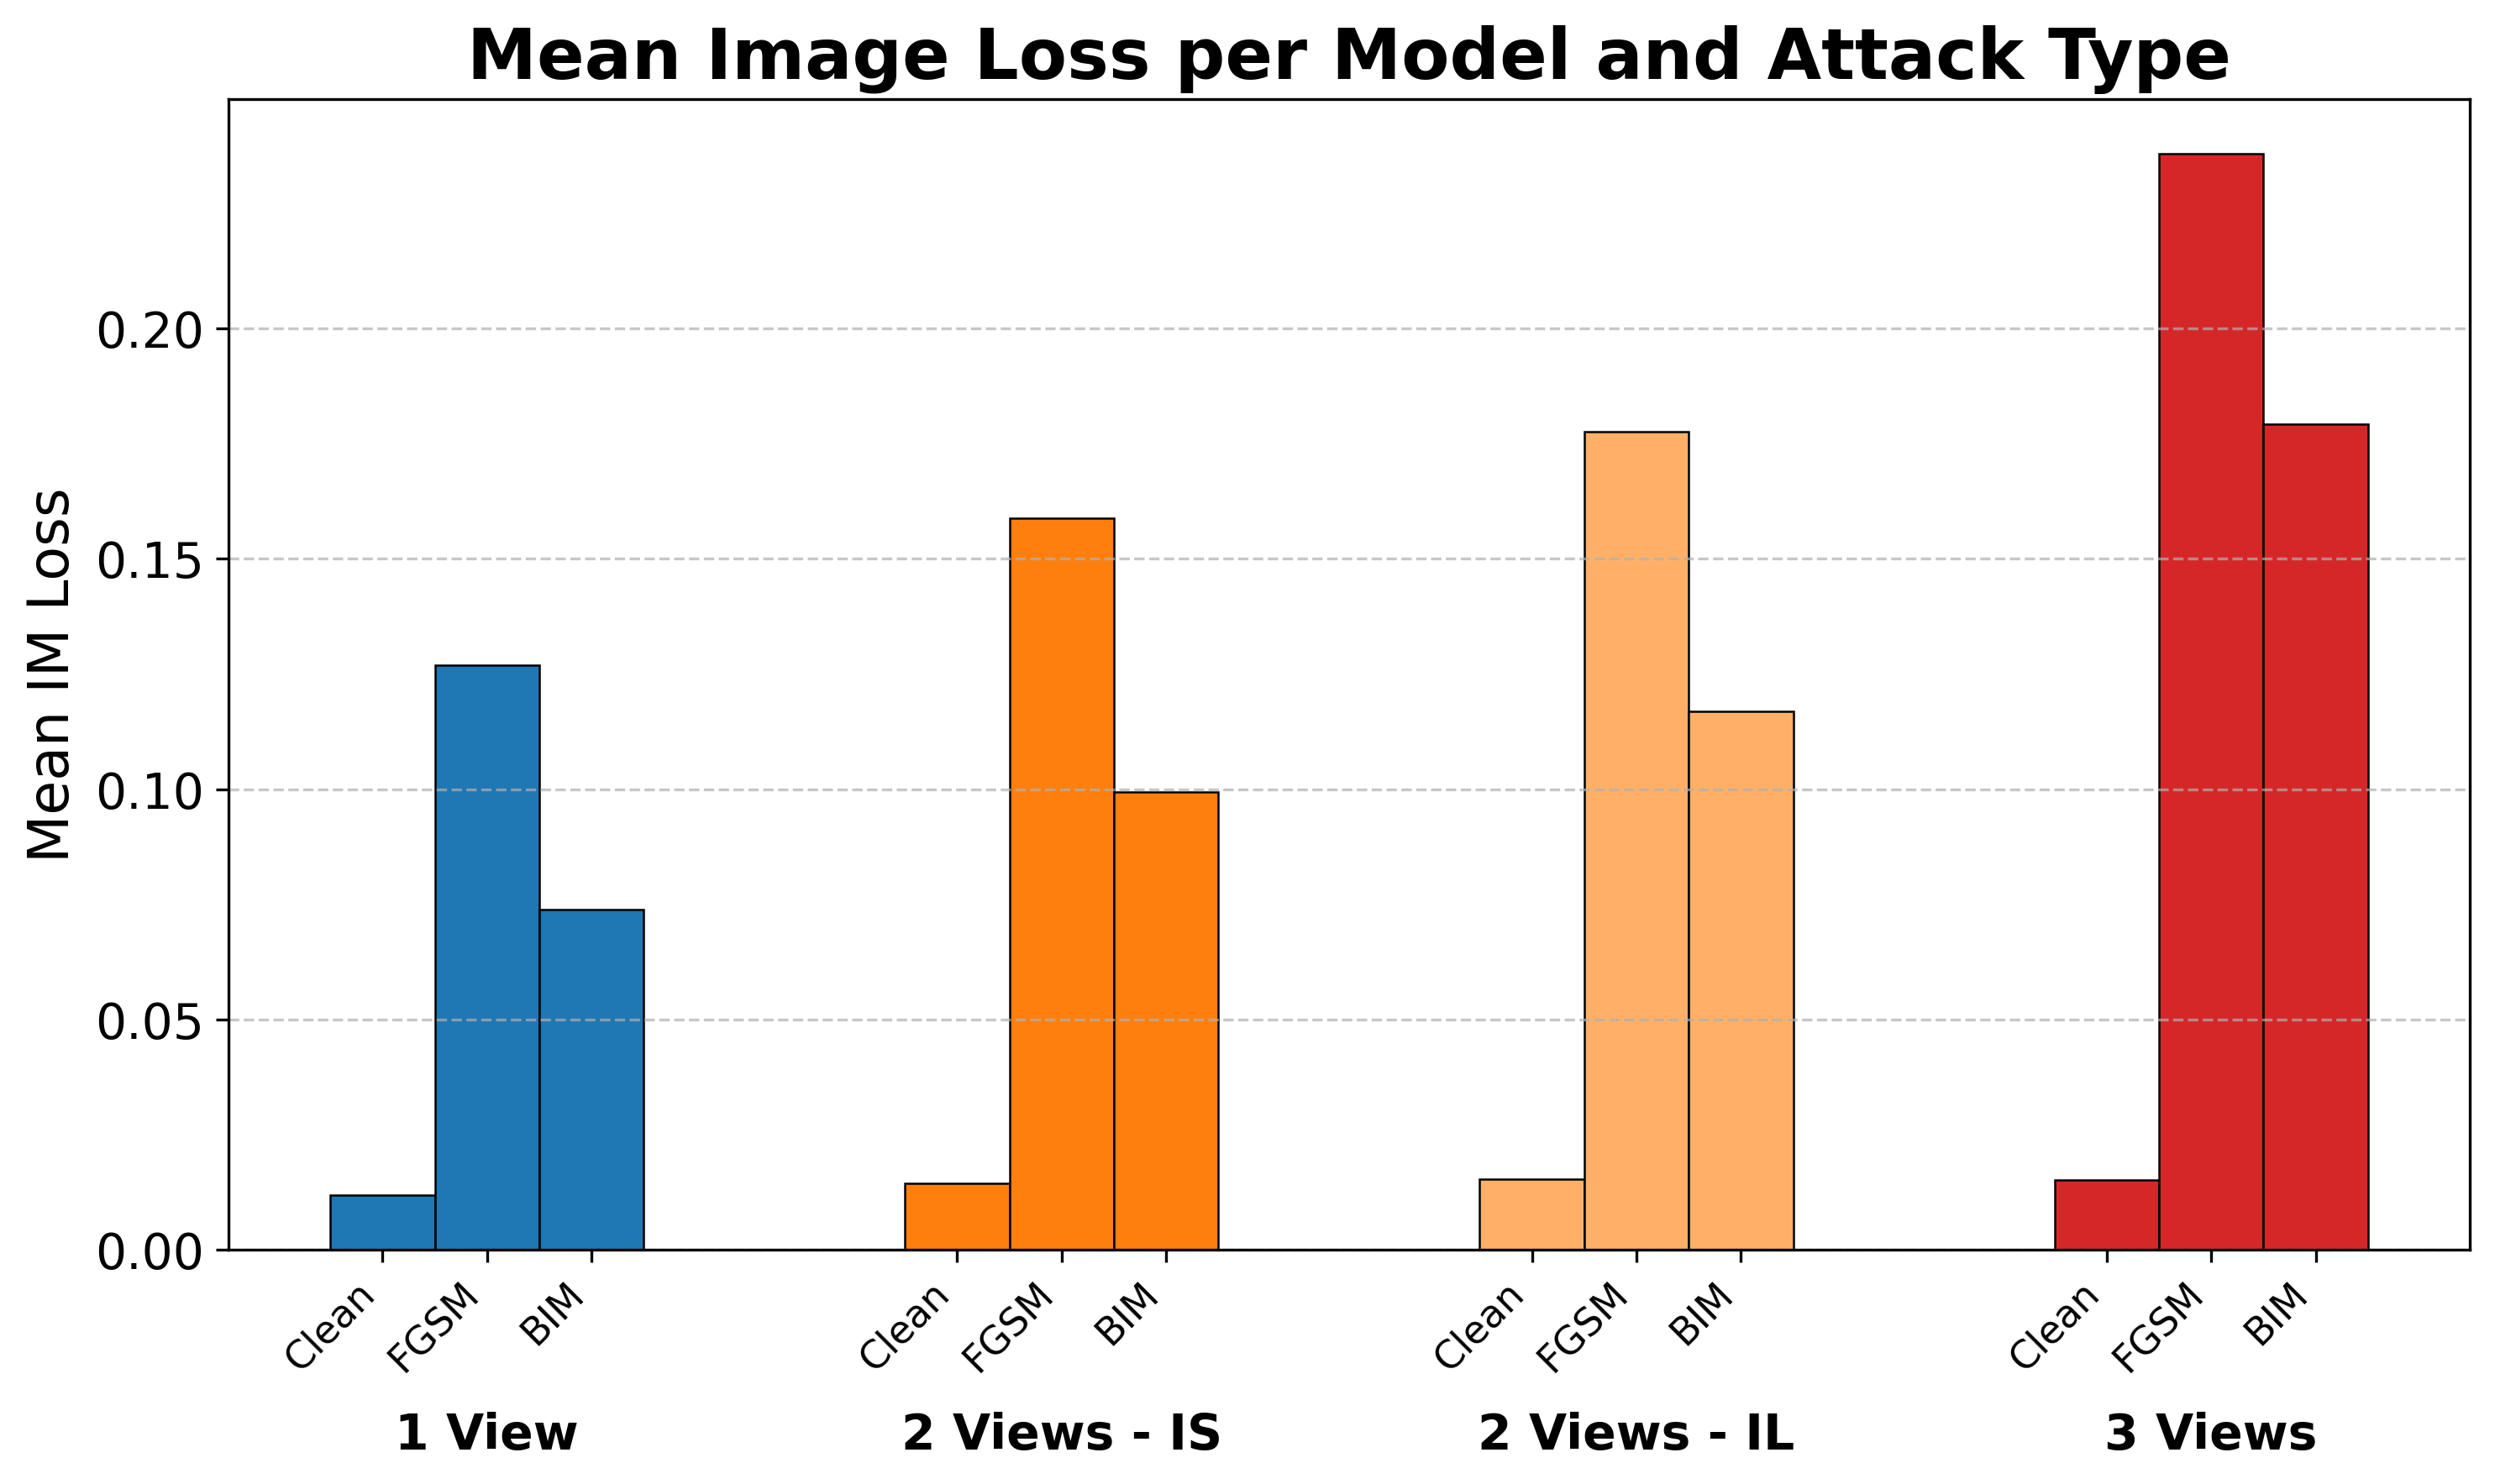

In [6]:
models = ['1V', '2V-IS', '2V-IL', '3V']

model_color_map = {
    '1V': 'tab:blue',
    '2V-IS': 'tab:orange',
    '2V-IL': '#ffb066',
    '3V': 'tab:red'
}

model_label_map = {
    '1V': '1 View',
    '2V-IS': '2 Views - IS',
    '2V-IL': '2 Views - IL',
    '3V': '3 Views'
}

attack_values = {
    'Clean': mean_clean_loss['Clean_IM_Loss'].to_numpy(),
    'FGSM':  mean_clean_loss['FGSM_IM_Loss'].to_numpy(),
    'BIM':   mean_clean_loss['BIM_IM_Loss'].to_numpy()
}

attacks = list(attack_values.keys())

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

bar_width = 0.22
group_gap = 0.55

x_positions = []
x_labels = []

for i, model in enumerate(models):
    group_start = i * (len(attacks) * bar_width + group_gap)

    for j, attack in enumerate(attacks):
        xpos = group_start + j * bar_width
        x_positions.append(xpos)
        x_labels.append(attack)

        ax.bar(
            xpos,
            attack_values[attack][i],
            width=bar_width,
            color=model_color_map[model],
            edgecolor='black',
            linewidth=0.6
        )

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=11)

group_centers = [
    i * (len(attacks) * bar_width + group_gap) + (len(attacks) - 1) * bar_width / 2
    for i in range(len(models))
]

for center, model in zip(group_centers, models):
    ax.text(
        center,
        -0.14,
        model_label_map.get(model, model),
        ha='center',
        va='top',
        fontsize=14,
        fontweight='bold',
        transform=ax.get_xaxis_transform()
    )

ax.set_title('Mean Image Loss per Model and Attack Type', fontsize=20, fontweight='bold')
ax.set_ylabel('Mean IM Loss', fontsize=16)

ax.tick_params(axis='y', labelsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

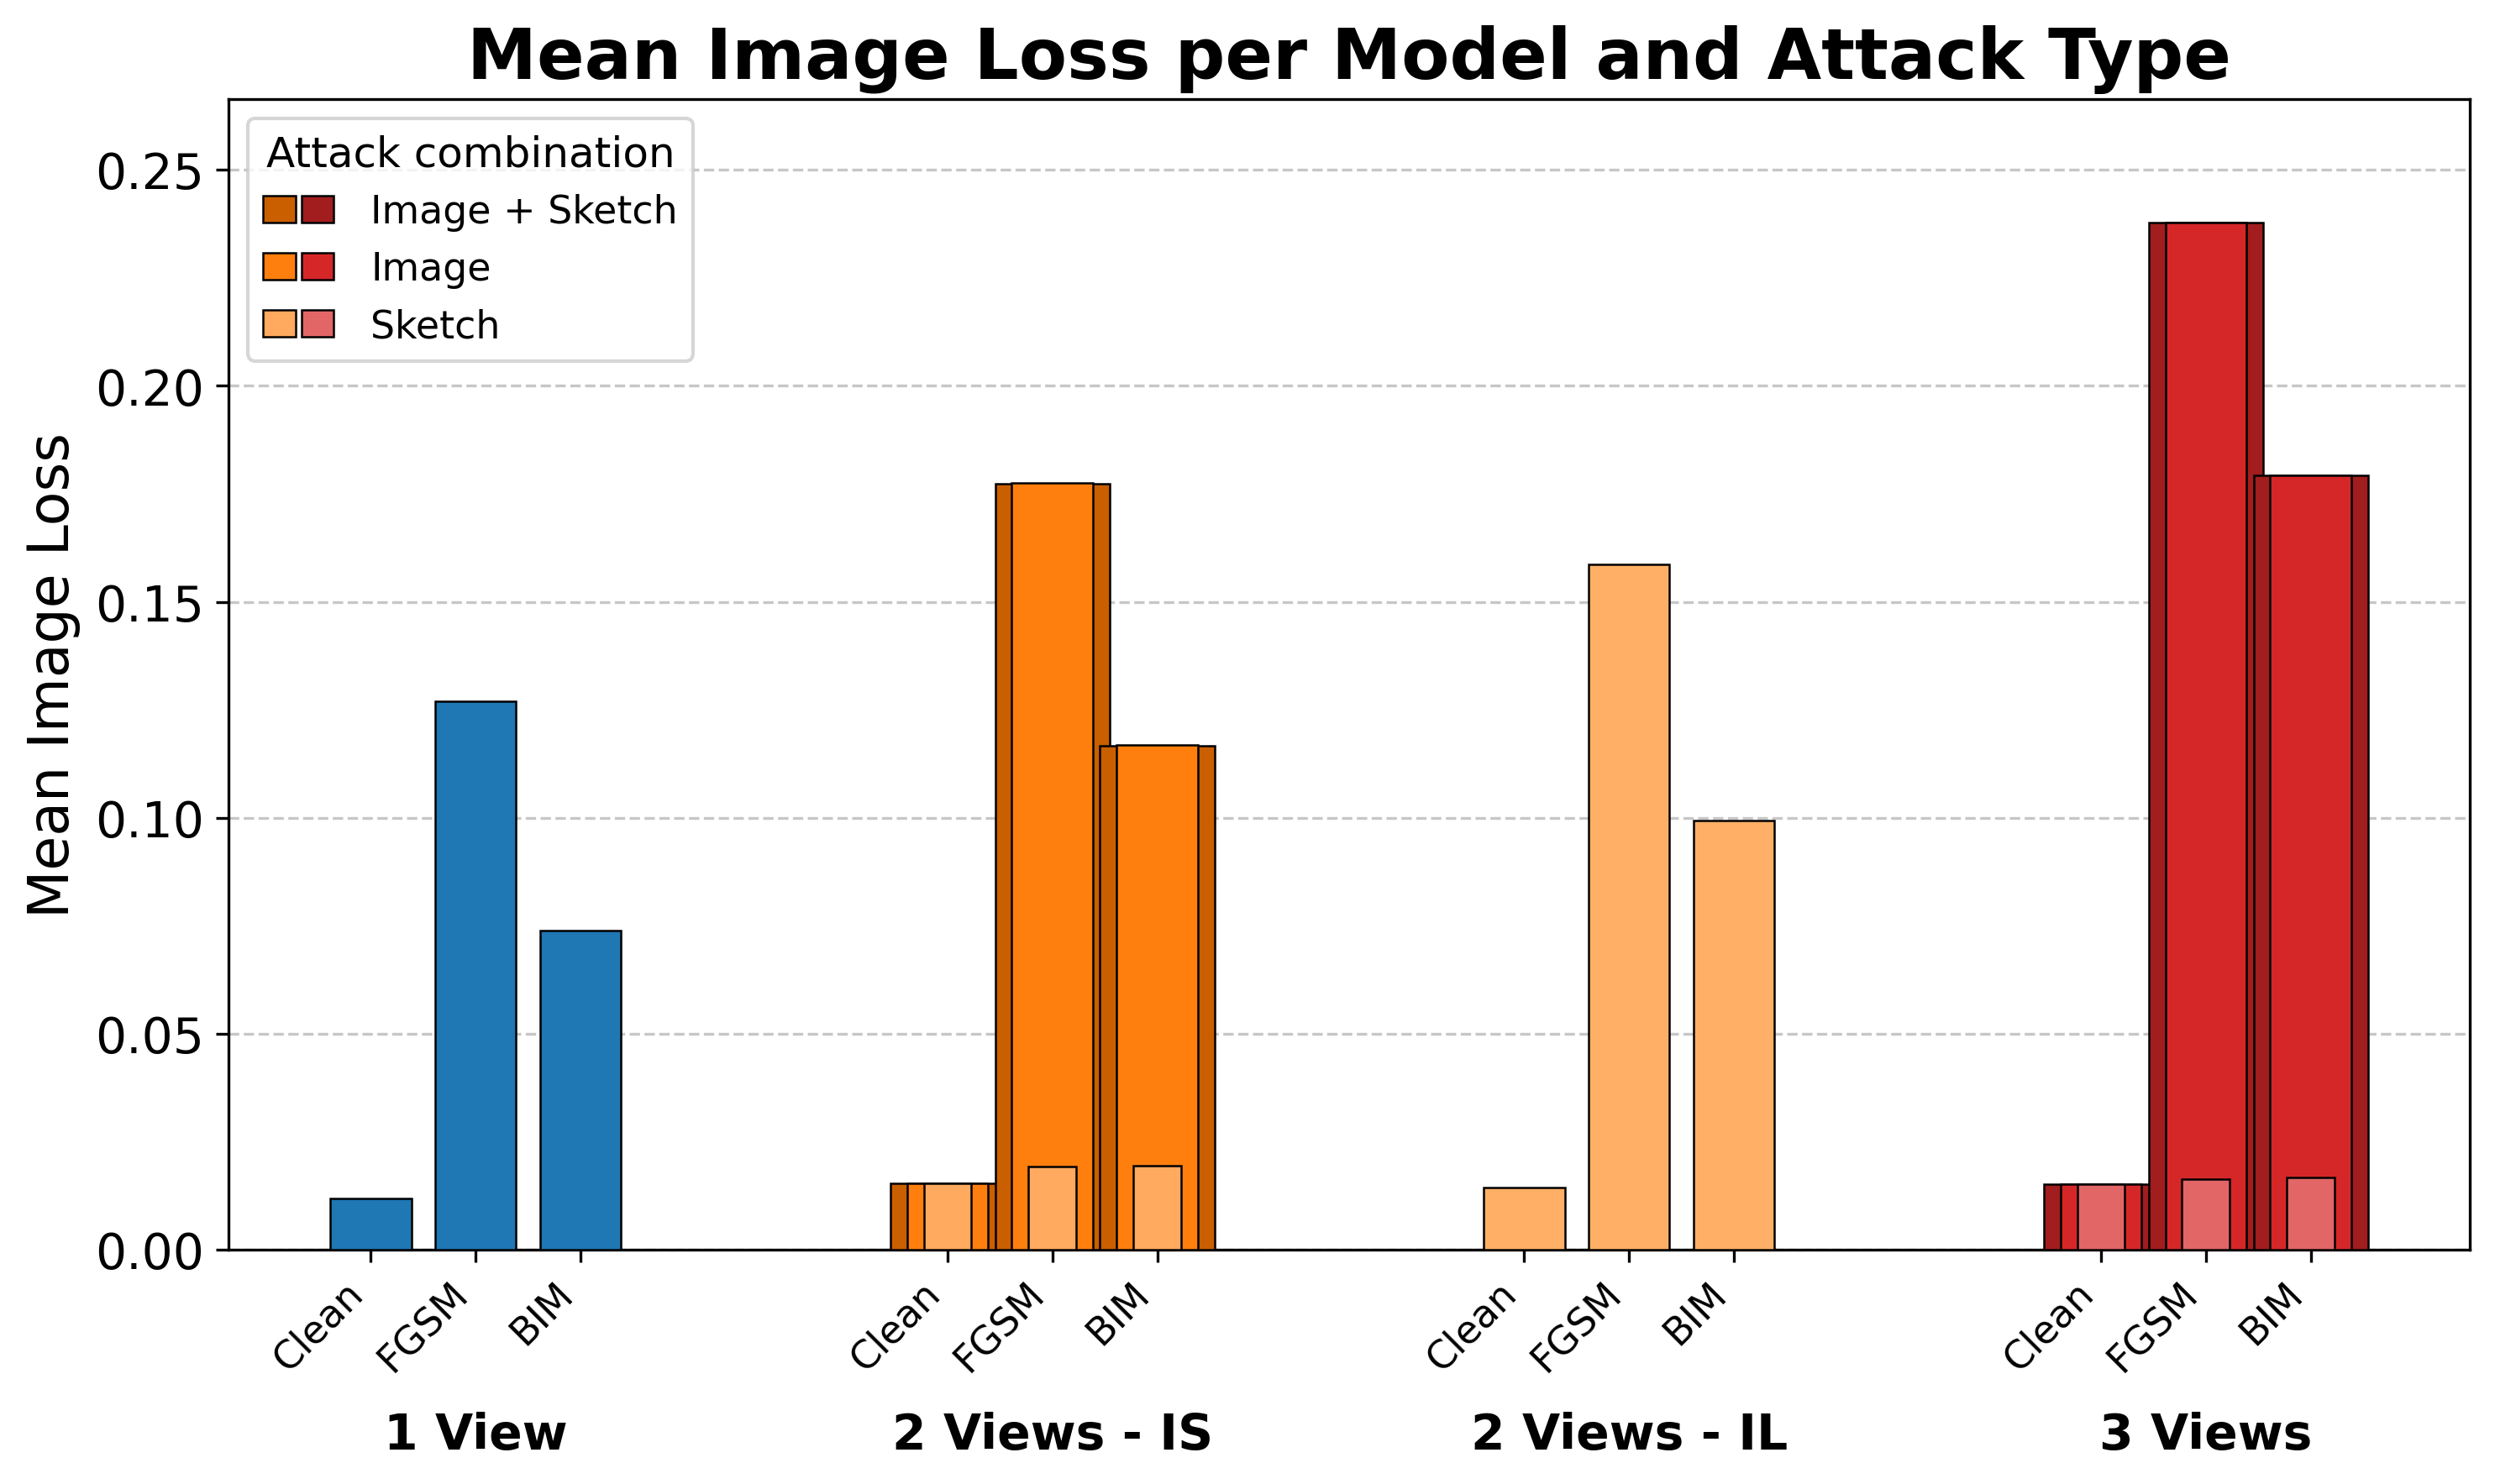

In [20]:
plot_df = (
    df[
        ((df['image_attack'] == True) & (df['sketch_attack'] == True)) |
        ((df['image_attack'] == True) & (df['sketch_attack'] == False)) |
        ((df['image_attack'] == False) & (df['sketch_attack'] == True))
    ]
    .groupby(['model', 'image_attack', 'sketch_attack'])[
        ['Clean_IM_Loss', 'FGSM_IM_Loss', 'BIM_IM_Loss']
    ]
    .mean()
    .reset_index()
)

model_order = ['1V', '2V-IS', '2V-IL', '3V']

model_label_map = {
    '1V': '1 View',
    '2V-IL': '2 Views - IL',
    '2V-IS': '2 Views - IS',
    '3V': '3 Views'
}

# Base colors depend on the model/view type
model_color_map = {
    '1V': 'tab:blue',
    '2V-IL': '#ffb066',
    '2V-IS': 'tab:orange',
    '3V': 'tab:red'
}

loss_names = ['Clean', 'FGSM', 'BIM']

loss_col_map = {
    'Clean': 'Clean_IM_Loss',
    'FGSM': 'FGSM_IM_Loss',
    'BIM': 'BIM_IM_Loss'
}

combo_order = [
    (True, True),     # widest / back
    (True, False),    # middle
    (False, True)     # narrowest / front
]

combo_labels = {
    (True, True): 'Image + Sketch',
    (True, False): 'Image',
    (False, True): 'Sketch'
}

# Helper to create similar colors for overlapping bars
def adjust_color(color, amount=1.0):
    """
    amount < 1.0 makes color darker
    amount > 1.0 makes color lighter
    """
    import matplotlib.colors as mc
    import colorsys

    try:
        c = mc.cnames[color]
    except KeyError:
        c = color

    r, g, b = mc.to_rgb(c)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = max(0, min(1, amount * l))

    return colorsys.hls_to_rgb(h, l, s)

# Similar shades per attack combination
combo_shade_map = {
    (True, True): 0.75,    # darker, widest / back
    (True, False): 1.00,   # base color, middle
    (False, True): 1.30    # lighter, narrowest / front
}

# Custom legend: two color patches on one row
class HandlerDoublePatch(HandlerBase):
    def create_artists(
        self, legend, orig_handle, xdescent, ydescent,
        width, height, fontsize, trans
    ):
        color1, color2 = orig_handle

        patch_width = width * 0.42
        gap = width * 0.08

        p1 = Rectangle(
            (xdescent, ydescent),
            patch_width,
            height,
            facecolor=color1,
            edgecolor='black',
            linewidth=0.6,
            transform=trans
        )

        p2 = Rectangle(
            (xdescent + patch_width + gap, ydescent),
            patch_width,
            height,
            facecolor=color2,
            edgecolor='black',
            linewidth=0.6,
            transform=trans
        )

        return [p1, p2]

# Lookup table
lookup = {}
for _, row in plot_df.iterrows():
    lookup[(row['model'], row['image_attack'], row['sketch_attack'])] = row

bar_width = 0.22
group_gap = 0.55

x_positions = []
x_labels = []

for i, model in enumerate(model_order):
    group_start = i * (len(loss_names) * bar_width + group_gap)

    for j, loss in enumerate(loss_names):
        xpos = group_start + j * bar_width
        x_positions.append(xpos)
        x_labels.append((model, loss))

# Overlapping bar widths
widths = {
    (True, True): 0.24,
    (True, False): 0.17,
    (False, True): 0.10
}

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

for i, combo in enumerate(combo_order):
    heights = []
    colors = []

    for model, loss_name in x_labels:
        row = lookup.get((model, combo[0], combo[1]))

        if row is None:
            heights.append(np.nan)
        else:
            heights.append(row[loss_col_map[loss_name]])

        colors.append(
            adjust_color(
                model_color_map[model],
                combo_shade_map[combo]
            )
        )

    ax.bar(
        x_positions,
        heights,
        width=widths[combo],
        color=colors,
        edgecolor='black',
        linewidth=0.6,
        label=combo_labels[combo],
        zorder=3 + i
    )

# Attack names as sub x-ticks
ax.set_xticks(x_positions)
ax.set_xticklabels(
    [loss for _, loss in x_labels],
    rotation=45,
    ha='right',
    fontsize=11
)

# Add model labels centered underneath each attack group
group_centers = [
    i * (len(loss_names) * bar_width + group_gap) + (len(loss_names) - 1) * bar_width / 2
    for i in range(len(model_order))
]

for center, model in zip(group_centers, model_order):
    ax.text(
        center,
        -0.14,
        model_label_map.get(model, model),
        ha='center',
        va='top',
        fontsize=14,
        fontweight='bold',
        transform=ax.get_xaxis_transform()
    )

# Add a bit of headroom
all_vals = []
for row in lookup.values():
    all_vals.extend([
        row['Clean_IM_Loss'],
        row['FGSM_IM_Loss'],
        row['BIM_IM_Loss']
    ])

ax.set_ylim(0, max(all_vals) * 1.12)

ax.set_ylabel('Mean Image Loss', fontsize=16)
ax.set_title('Mean Image Loss per Model and Attack Type', fontsize=20, fontweight='bold')

ax.tick_params(axis='y', labelsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Legend with one line per attack combination
legend_handles = []
legend_labels = []

for combo in combo_order:
    legend_handles.append((
        adjust_color(model_color_map['2V-IS'], combo_shade_map[combo]),
        adjust_color(model_color_map['3V'], combo_shade_map[combo])
    ))
    legend_labels.append(combo_labels[combo])

ax.legend(
    legend_handles,
    legend_labels,
    handler_map={tuple: HandlerDoublePatch()},
    title='Attack combination',
    loc='upper left',
    fontsize=11,
    title_fontsize=12
)

plt.tight_layout()
plt.show()

/var/folders/yd/xmg755ln3fscr3pf2_0xpclm0000gn/T/ipykernel_96897/1103264195.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


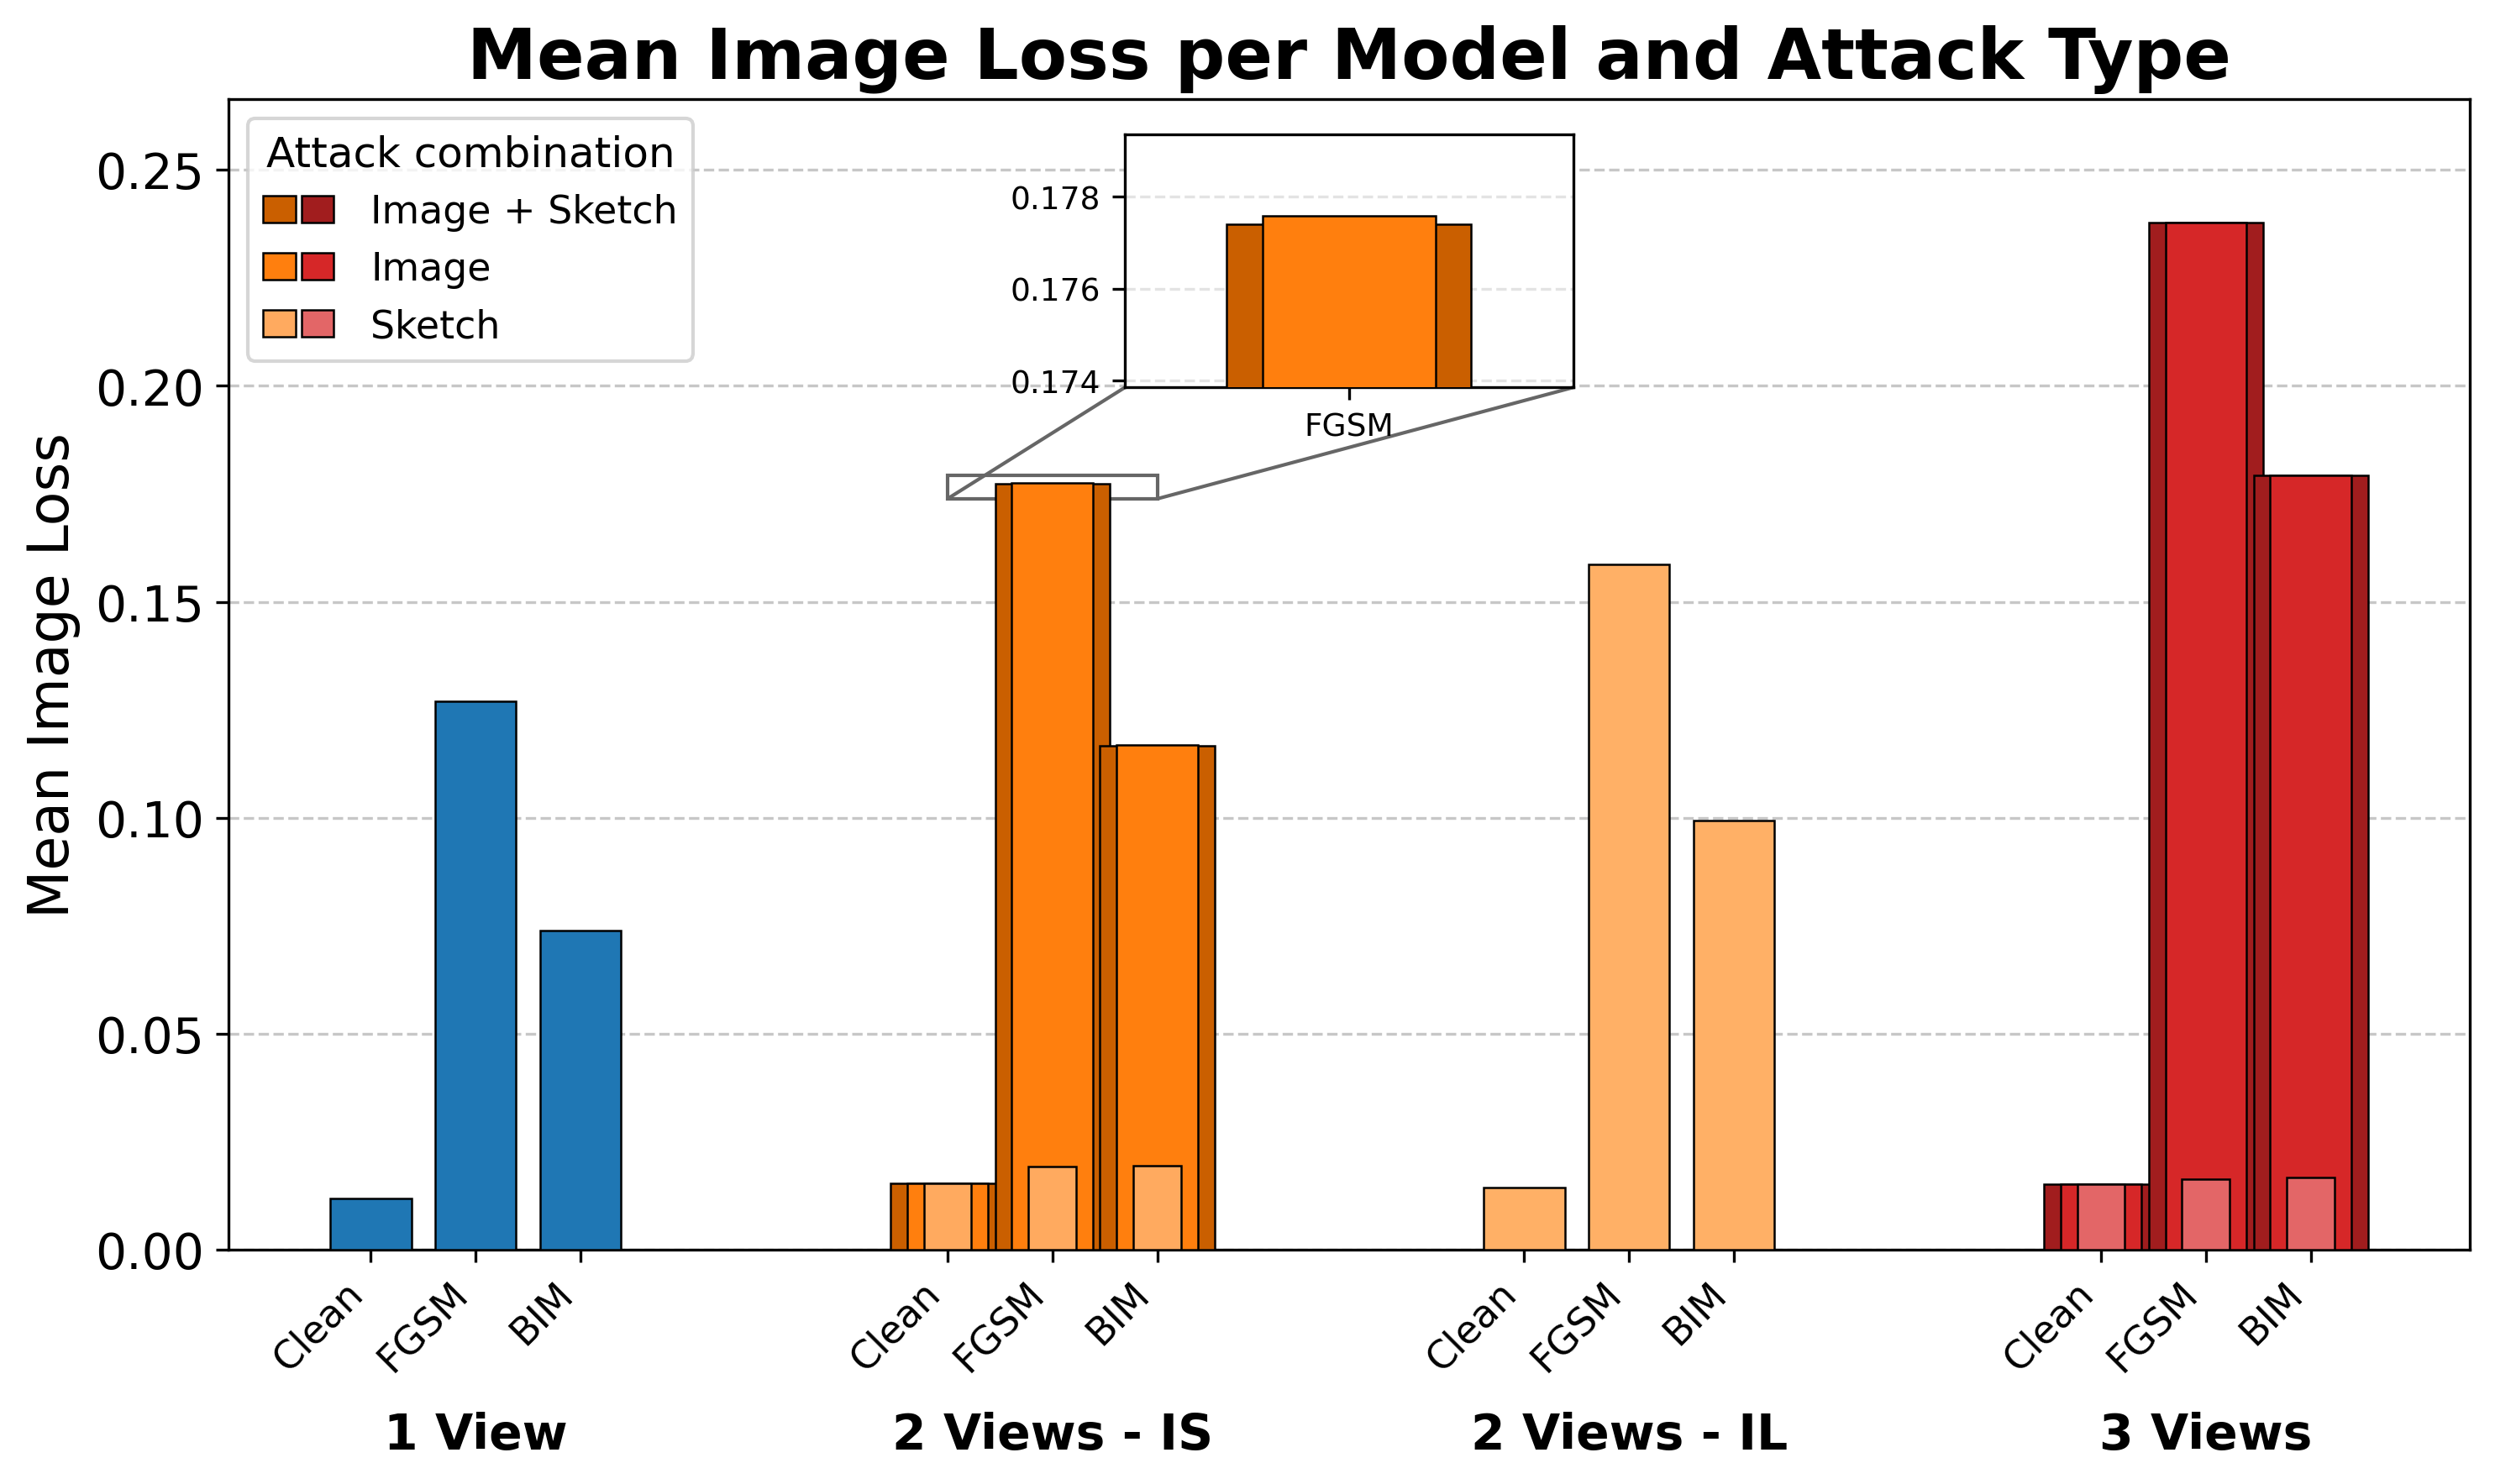

In [21]:
# Lookup table
lookup = {}
for _, row in plot_df.iterrows():
    lookup[(row['model'], row['image_attack'], row['sketch_attack'])] = row

bar_width = 0.22
group_gap = 0.55

x_positions = []
x_labels = []

for i, model in enumerate(model_order):
    group_start = i * (len(loss_names) * bar_width + group_gap)

    for j, loss in enumerate(loss_names):
        xpos = group_start + j * bar_width
        x_positions.append(xpos)
        x_labels.append((model, loss))

widths = {
    (True, True): 0.24,
    (True, False): 0.17,
    (False, True): 0.10
}

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

combo_heights = {}
combo_colors = {}

for i, combo in enumerate(combo_order):
    heights = []
    colors = []

    for model, loss_name in x_labels:
        row = lookup.get((model, combo[0], combo[1]))

        if row is None:
            heights.append(np.nan)
        else:
            heights.append(row[loss_col_map[loss_name]])

        colors.append(
            adjust_color(
                model_color_map[model],
                combo_shade_map[combo]
            )
        )

    combo_heights[combo] = heights
    combo_colors[combo] = colors

    ax.bar(
        x_positions,
        heights,
        width=widths[combo],
        color=colors,
        edgecolor='black',
        linewidth=0.6,
        zorder=3 + i
    )

# Attack names as sub x-ticks
ax.set_xticks(x_positions)
ax.set_xticklabels(
    [loss for _, loss in x_labels],
    rotation=45,
    ha='right',
    fontsize=11
)

# Model labels centered underneath each attack group
group_centers = [
    i * (len(loss_names) * bar_width + group_gap) + (len(loss_names) - 1) * bar_width / 2
    for i in range(len(model_order))
]

for center, model in zip(group_centers, model_order):
    ax.text(
        center,
        -0.14,
        model_label_map.get(model, model),
        ha='center',
        va='top',
        fontsize=14,
        fontweight='bold',
        transform=ax.get_xaxis_transform()
    )

all_vals = []
for row in lookup.values():
    all_vals.extend([
        row['Clean_IM_Loss'],
        row['FGSM_IM_Loss'],
        row['BIM_IM_Loss']
    ])

ax.set_ylim(0, max(all_vals) * 1.12)
ax.set_ylabel('Mean Image Loss', fontsize=16)
ax.set_title('Mean Image Loss per Model and Attack Type', fontsize=20, fontweight='bold')

ax.tick_params(axis='y', labelsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Legend with one row per attack combination
legend_handles = []
legend_labels = []

for combo in combo_order:
    legend_handles.append((
        adjust_color(model_color_map['2V-IS'], combo_shade_map[combo]),
        adjust_color(model_color_map['3V'], combo_shade_map[combo])
    ))
    legend_labels.append(combo_labels[combo])

ax.legend(
    legend_handles,
    legend_labels,
    handler_map={tuple: HandlerDoublePatch()},
    title='Attack combination',
    loc='upper left',
    fontsize=11,
    title_fontsize=12
)

# Inset at top center
axins = inset_axes(
    ax,
    width="20%",
    height="22%",
    loc='upper center',
    borderpad=1.0
)

for i, combo in enumerate(combo_order):
    axins.bar(
        x_positions,
        combo_heights[combo],
        width=widths[combo],
        color=combo_colors[combo],
        edgecolor='black',
        linewidth=0.6,
        zorder=3 + i
    )

# 2V-IS FGSM bar only
start_2vis = model_order.index('2V-IS') * len(loss_names)
fgsm_idx = start_2vis + loss_names.index('FGSM')
x_fgsm = x_positions[fgsm_idx]

# Only use non-sketch-only combos for zoom calculation
inset_combos = [(True, True), (True, False)]
vals_fgsm = []

for combo in inset_combos:
    v = combo_heights[combo][fgsm_idx]
    if not np.isnan(v):
        vals_fgsm.append(v)

axins.set_xlim(x_fgsm - 0.22, x_fgsm + 0.22)
axins.set_ylim(min(vals_fgsm) * 0.98, max(vals_fgsm) * 1.01)

axins.set_xticks([x_fgsm])
axins.set_xticklabels(['FGSM'], fontsize=9)
axins.tick_params(axis='y', labelsize=9)
axins.grid(axis='y', linestyle='--', alpha=0.35)

mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec="0.4", lw=1)

plt.tight_layout()
plt.show()

## Clean

In [9]:
mean_clean_loss2 = (
    df[
        (df['image_attack'] == True) &
        (df['sketch_attack'] == False)
    ]
    .groupby(['model', 'image_attack', 'sketch_attack'])[
        ['Clean_IM_Loss', 'FGSM_IM_Loss', 'BIM_IM_Loss']
    ]
    .mean()
    .reset_index()
)

In [10]:
df_stat_test = df[
    ((df['model'] == '1V')    & (df['image_attack'] == True) & (df['sketch_attack'] == False)) |
    ((df['model'] == '2V-IL') & (df['image_attack'] == True) & (df['sketch_attack'] == False)) |
    ((df['model'] == '2V-IS') & (df['image_attack'] == True) & (df['sketch_attack'] == False)) |
    ((df['model'] == '3V')    & (df['image_attack'] == True) & (df['sketch_attack'] == False))
].copy()

# Extract the 4 groups
g_1v    = df_stat_test.loc[df_stat_test['model'] == '1V', 'Clean_IM_Loss']
g_2vil  = df_stat_test.loc[df_stat_test['model'] == '2V-IL', 'Clean_IM_Loss']
g_2vis  = df_stat_test.loc[df_stat_test['model'] == '2V-IS', 'Clean_IM_Loss']
g_3v    = df_stat_test.loc[df_stat_test['model'] == '3V', 'Clean_IM_Loss']

# Optional sanity check
print(df_stat_test.groupby('model').size())

# Kruskal-Wallis test
h_stat, p_value = kruskal(g_1v, g_2vil, g_2vis, g_3v)

print(f"H-statistic: {h_stat:.6f}")
print(f"P-value: {p_value:.6e}")

model
1V       10
2V-IL    10
2V-IS    10
3V       10
dtype: int64
H-statistic: 26.499512
P-value: 7.495682e-06


1V       a 
2V-IL     b
2V-IS     b
3V        b
Name: letters, dtype: object


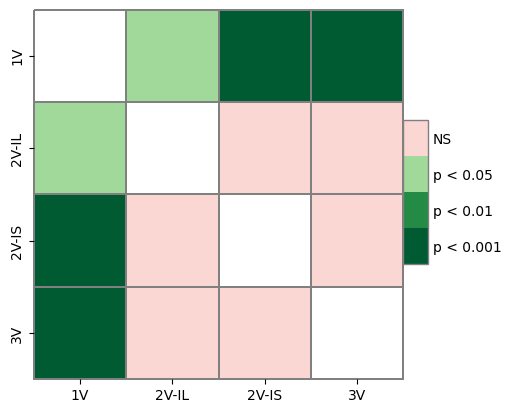

In [11]:
dunn_results = sp.posthoc_dunn(
    df_stat_test,
    val_col='Clean_IM_Loss',
    group_col='model',
    p_adjust='holm'   # or 'holm', 'fdr_bh'
)

heatmap_args = {'linewidths': 0.25, 'linecolor': '0.5', 'clip_on': False, 'square': True, 'cbar_ax_bbox': [0.80, 0.35, 0.04, 0.3]}
sp.sign_plot(dunn_results, **heatmap_args) # a is significantly different from b

print(sp.compact_letter_display(dunn_results)) # a is significantly different from b
# print(dunn_results)

## FGSM

1V       a  
2V-IL    ab 
2V-IS     bc
3V         c
Name: letters, dtype: object


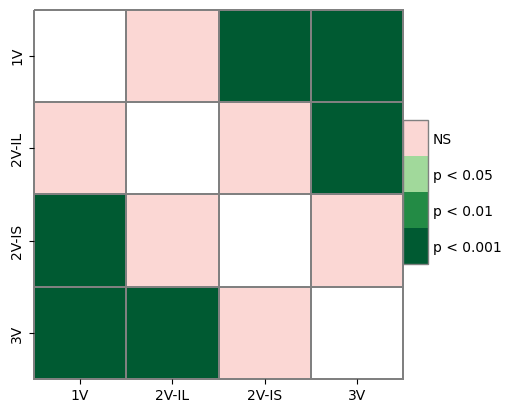

In [12]:
dunn_results = sp.posthoc_dunn(
    df_stat_test,
    val_col='FGSM_IM_Loss',
    group_col='model',
    p_adjust='holm'   # or 'holm', 'fdr_bh'
)

heatmap_args = {'linewidths': 0.25, 'linecolor': '0.5', 'clip_on': False, 'square': True, 'cbar_ax_bbox': [0.80, 0.35, 0.04, 0.3]}
sp.sign_plot(dunn_results, **heatmap_args) # a is significantly different from b

print(sp.compact_letter_display(dunn_results)) # a is significantly different from b
# print(dunn_results)

## BIM

1V       a  
2V-IL    ab 
2V-IS     bc
3V         c
Name: letters, dtype: object


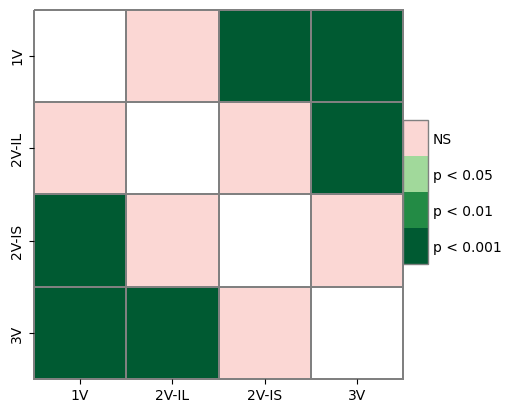

In [13]:
dunn_results = sp.posthoc_dunn(
    df_stat_test,
    val_col='BIM_IM_Loss',
    group_col='model',
    p_adjust='holm'   # or 'holm', 'fdr_bh'
)

heatmap_args = {'linewidths': 0.25, 'linecolor': '0.5', 'clip_on': False, 'square': True, 'cbar_ax_bbox': [0.80, 0.35, 0.04, 0.3]}
sp.sign_plot(dunn_results, **heatmap_args) # a is significantly different from b

print(sp.compact_letter_display(dunn_results)) # a is significantly different from b
# print(dunn_results)

## IS VS I only

In [14]:
df_stat_test_2 = df[
    ((df['model'] == '1V')    & (df['image_attack'] == True)) |
    ((df['model'] == '2V-IL') & (df['image_attack'] == True)) |
    ((df['model'] == '2V-IS') & (df['image_attack'] == True)) |
    ((df['model'] == '3V')    & (df['image_attack'] == True))
].copy()

In [15]:
df_stat_test_2.head()

,model,image_attack,sketch_attack,Clean_IM_Loss,FGSM_IM_Loss,BIM_IM_Loss,Clean_SK_Loss,FGSM_SK_Loss,BIM_SK_Loss,Clean_LA_Loss,FGSM_LA_Loss,BIM_LA_Loss
0,3V,True,True,0.014524,0.239832,0.181438,0.059129,0.074593,0.066791,0.001540,0.038809,0.010188
1,3V,True,True,0.015393,0.220886,0.165209,0.059679,0.074099,0.066236,0.000997,0.015301,0.006461
2,3V,True,True,0.014677,0.224152,0.166810,0.056570,0.071467,0.063751,0.001310,0.043505,0.008856
3,3V,True,True,0.015958,0.242522,0.182911,0.057411,0.072124,0.064613,0.001788,0.037404,0.008774
4,3V,True,True,0.015271,0.240027,0.181095,0.058963,0.074115,0.066429,0.001093,0.029024,0.008979


In [16]:
g_1 = df_stat_test_2.loc[
    (df_stat_test_2['image_attack']) & (df_stat_test_2['sketch_attack'])
].groupby('model')['FGSM_IM_Loss'].apply(list)

g_2 = df_stat_test_2.loc[
    (df_stat_test_2['image_attack']) & ~(df_stat_test_2['sketch_attack'])
].groupby('model')['FGSM_IM_Loss'].apply(list)

In [17]:
g_1

model
2V-IS    [0.1807992913615296, 0.1762802476750412, 0.175...
3V       [0.2398322637893056, 0.2208860635245351, 0.224...
Name: FGSM_IM_Loss, dtype: object

In [18]:
t_stat, p_value = stats.ttest_rel(g_1.loc['3V'], g_2.loc['3V'])

print(f"T-statistic: {t_stat:.6f}")
print(f"P-value: {p_value:.6e}")

T-statistic: -1.519521
P-value: 1.629507e-01


In [19]:
t_stat, p_value = stats.ttest_rel(g_1.loc['2V-IS'], g_2.loc['2V-IS'])

print(f"T-statistic: {t_stat:.6f}")
print(f"P-value: {p_value:.6e}")

T-statistic: -2.375577
P-value: 4.152765e-02
